# CatSpeak AI Content Moderation — **DEMO ZH** Train Text Classifier (Colab T4)

Bản **chỉ tiếng Trung** (Hán tự + **phiên âm pinyin**), cùng pipeline với `train_text_classifier_demo_colab.ipynb`. Mục tiêu: chạy trọn vẹn trên **Google Colab GPU T4 miễn phí trong ~30–60 phút** và ra **model ONNX INT8 thay thế trực tiếp** cho `demo/models/xlmr_onnx_int8/`.

**Khác gì bản demo đa ngôn ngữ:**

| | Bản demo đa ngôn ngữ | Bản ZH này |
|---|---|---|
| Dataset | ViHSD (Vi) + Jigsaw (En) + COLD (Zh) | **COLD (Zh) duy nhất** + **augment pinyin bằng `pypinyin`** |
| Ngôn ngữ | vi / en / zh | **zh (Hán tự) + zh_pinyin (phiên âm có dấu & không dấu)** |
| ML | 3 model + Soft Voting | giữ nguyên |
| XLM-R | freeze bottom-6, 2 epoch | giữ nguyên (cùng base model → **cùng tokenizer**) |
| ViT image | inference-only | **bỏ** (model ảnh không đổi, backend giữ nguyên) |
| ONNX INT8 | ✅ | ✅ (cùng cấu trúc thư mục → drop-in) |

**Vì sao augment pinyin?** Không có dataset toxic tiếng Trung dạng pinyin công khai, nhưng user thực tế gõ `cao ni ma`, `sha bi`… để lách filter. Ta sinh bản pinyin (có dấu thanh `nǐ shì shǎ bī` và không dấu `ni shi sha bi`) từ chính COLD bằng `pypinyin` — **augment SAU khi split** để bản pinyin của câu train không lọt vào test (tránh leakage). XLM-R vẫn là `FacebookAI/xlm-roberta-base` nên tokenizer SentencePiece xử lý pinyin (latin) lẫn Hán tự tốt.

**Cách chạy trên Colab:**
1. Upload notebook này lên [colab.research.google.com](https://colab.research.google.com) (File → Upload notebook).
2. **Runtime → Change runtime type → T4 GPU** → Save.
3. **Runtime → Run all**. Không cần upload gì thêm (COLD tải thẳng từ GitHub).
4. Xong sẽ tự tải về `artifacts_demo_zh.zip` → giải nén, copy `artifacts/xlmr_onnx_int8/` **đè vào** `demo/models/xlmr_onnx_int8/` là demo chạy tiếng Trung.

Seed = 42. Nhãn giữ nguyên `CLEAN / OFFENSIVE / HATE` → **không phải sửa backend/frontend**.


## 1. Setup (cài thư viện + kiểm tra GPU)

In [ ]:
# Cai thu vien — PIN transformers 4.53.3 (Trainer API on dinh voi code notebook nay).
# KHONG dung optimum: ban optimum/diffusers tren Colab moi xung dot nhau va xung dot torch
# (thieu _attention_scale) -> muc 9 export ONNX truc tiep bang torch.onnx + onnxruntime.
!pip uninstall -q -y diffusers
!pip install -q "transformers==4.53.3" datasets accelerate xgboost pypinyin onnxruntime

import os, random, numpy as np, torch, warnings
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IN_COLAB = "COLAB_RELEASE_TAG" in os.environ or os.path.exists("/content")
import transformers
print("Colab:", IN_COLAB, "| transformers:", transformers.__version__, "| torch:", torch.__version__)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available()
      else "!!! KHONG co GPU — bat T4: Runtime > Change runtime type > T4 GPU roi Restart")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 840.2/840.2 kB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 55.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
Colab: True | transformers: 4.53.3 | torch: 2.11.0+cu128
GPU: Tesla T4


## 2. Cấu hình demo ZH

In [ ]:
LABELS   = ["CLEAN", "OFFENSIVE", "HATE"]
LABEL2ID = {l: i for i, l in enumerate(LABELS)}

# ---- Cong tac ----
RUN_ML = True    # Phan 5: ML rut gon (3 model + soft voting)

# ---- Gioi han (chi 1 dataset nen cap cao hon ban da ngon ngu) ----
MAX_PER_DATASET   = 32_000   # COLD full ~37k -> giu gan het
CLEAN_RATIO_CAP   = 2.0      # CLEAN toi da = 2x (OFFENSIVE+HATE)
MAX_TRAIN_SAMPLES = 30_000   # cap tap train XLM-R SAU augment pinyin
N_ML_SAMPLE       = 20_000   # cap so mau cho phan ML (TF-IDF)

# ---- Augment pinyin ----
PINYIN_FRAC_TRAIN = 0.50     # 50% mau train co Han tu duoc nhan ban sang pinyin
PINYIN_FRAC_EVAL  = 0.30     # 30% val/test -> do rieng F1 tren pinyin
PINYIN_TONE_RATIO = 0.5      # trong so mau pinyin: 50% co dau thanh, 50% khong dau

MAX_LEN = 128  # do dai token XLM-R (Han tu ~1 token/ky tu)


## 3. Load COLD (Zh) → schema chung `{text, label, lang, source}` + sinh phiên âm

| # | Nguồn | Ngôn ngữ | Cách lấy | Mapping về 3 nhãn |
|---|-------|----------|----------|-------------------|
| 1 | COLD (thu-coai/COLDataset) | Zh Hán tự | GitHub raw, retry 3 lần/file | offensive=1→OFFENSIVE; fine-grained topic=2 (attack group)→HATE; 0→CLEAN |
| 2 | Pinyin augment | Zh phiên âm | `pypinyin` sinh từ chính COLD (sau split) | giữ nguyên nhãn câu gốc |

Nhãn giữ nguyên `CLEAN/OFFENSIVE/HATE` — cùng `id2label` với model đang chạy trong demo.

In [ ]:
import unicodedata, re, time
import pandas as pd

URL_RE, MENTION_RE = re.compile(r"https?://\S+|www\.\S+"), re.compile(r"@\w+")
HAN_RE = re.compile(r"[\u4e00-\u9fff]")

def clean_text(t):
    t = unicodedata.normalize("NFC", str(t))
    t = URL_RE.sub(" <URL> ", t); t = MENTION_RE.sub(" <USER> ", t)
    return re.sub(r"\s+", " ", t).strip()

TEXT_CANDS  = ["comment_text", "free_text", "text", "texts", "content", "comment", "sentence"]
LABEL_CANDS = ["label_id", "label", "labels", "toxic", "class", "target"]

def find_col(df, cands):
    low = {c.lower().strip(): c for c in df.columns}
    for c in cands:
        if c in low: return low[c]
    raise KeyError(f"Khong tim thay cot trong {list(df.columns)}")

def as_rows(df, tcol, label_series, lang, source):
    out = pd.DataFrame({"text": df[tcol].astype(str).map(clean_text),
                        "label": label_series.astype(int).values,
                        "lang": lang, "source": source})
    return out[out.text.str.len() > 1].drop_duplicates("text")

def balance_clean(df, ratio=CLEAN_RATIO_CAP, cap=MAX_PER_DATASET):
    # Downsample CLEAN ve toi da ratio x (so mau vi pham), roi cap tong ve `cap`
    bad = df[df.label > 0]; cln = df[df.label == 0]
    n_keep = int(min(len(cln), max(1, len(bad)) * ratio))
    df = pd.concat([bad, cln.sample(n_keep, random_state=SEED)])
    if len(df) > cap:
        df = df.groupby("label", group_keys=False).apply(
            lambda g: g.sample(int(len(g) * cap / len(df)) + 1, random_state=SEED))
    return df.sample(frac=1, random_state=SEED).reset_index(drop=True)


In [ ]:
# ---------- COLD (Zh) — retry 3 lan/file (raw.githubusercontent hay dinh 429) ----------
# Loader GIONG HET ban demo da ngon ngu (da chay OK tren Colab)
COLD_BASE = "https://raw.githubusercontent.com/thu-coai/COLDataset/main/COLDataset/"

def load_cold():
    dfs = []
    for f in ["train.csv", "dev.csv", "test.csv"]:
        for attempt in range(3):
            try:
                dfs.append(pd.read_csv(COLD_BASE + f)); break
            except Exception as e:
                print(f"  COLD {f} lan {attempt+1} fail:", str(e)[:60]); time.sleep(4)
    if not dfs: raise RuntimeError("COLD: khong tai duoc file nao (thu chay lai cell nay)")
    df = pd.concat(dfs, ignore_index=True)
    t, l = find_col(df, TEXT_CANDS), find_col(df, LABEL_CANDS)
    lab = (df[l].astype(int) > 0).astype(int) * LABEL2ID["OFFENSIVE"]
    fg = [c for c in df.columns if "fine" in c.lower()]
    if fg:  # fine-grained: 2 = attack group -> HATE
        lab[pd.to_numeric(df[fg[0]], errors="coerce") == 2] = LABEL2ID["HATE"]
    return balance_clean(as_rows(df, t, lab, "zh", "cold"))

print("==> cold")
full = load_cold().drop_duplicates("text").reset_index(drop=True)
report_df = pd.DataFrame([{"dataset": "cold", "rows": len(full),
                           **{LABELS[i]: int((full.label == i).sum()) for i in range(3)}}])
print(report_df.to_string(index=False))
print(f"\nTong (Han tu, truoc augment pinyin): {len(full):,} mau")


==> cold
dataset  rows  CLEAN  OFFENSIVE  HATE
   cold 32002  16628      13841  1533

Tong (Han tu, truoc augment pinyin): 32,002 mau


In [ ]:
# ---------- Split stratified theo label TRUOC, roi moi augment pinyin ----------
# (augment truoc khi split se bi leakage: ban pinyin cua cau train lot vao test)
from sklearn.model_selection import train_test_split

strat = full.label.astype(str)
train_df, tmp = train_test_split(full, test_size=0.2, random_state=SEED, stratify=strat)
val_df, test_df = train_test_split(tmp, test_size=0.5, random_state=SEED,
                                   stratify=tmp.label.astype(str))

# ---------- Sinh phien am bang pypinyin ----------
from pypinyin import lazy_pinyin, Style

def to_pinyin(t, tone=False):
    # errors="default": ky tu khong phai Han tu (so, latin, dau cau) giu nguyen
    sylls = lazy_pinyin(t, style=Style.TONE if tone else Style.NORMAL, errors="default")
    return re.sub(r"\s+", " ", " ".join(sylls)).strip()

def augment_pinyin(df, frac, split_name):
    src = df[df.text.str.contains(HAN_RE)]
    n = int(len(src) * frac)
    if n == 0: return df
    pick = src.sample(n, random_state=SEED)
    n_tone = int(n * PINYIN_TONE_RATIO)
    rows = []
    for i, (_, r) in enumerate(pick.iterrows()):
        py = to_pinyin(r.text, tone=(i < n_tone))
        if len(py) > 1:
            rows.append({"text": py, "label": r.label, "lang": "zh_pinyin", "source": "cold_pinyin"})
    aug = pd.DataFrame(rows).drop_duplicates("text")
    out = pd.concat([df, aug], ignore_index=True).drop_duplicates("text")
    out = out.sample(frac=1, random_state=SEED).reset_index(drop=True)
    print(f"{split_name}: {len(df):,} -> {len(out):,} (+{len(out)-len(df):,} pinyin)")
    return out

train_df = augment_pinyin(train_df, PINYIN_FRAC_TRAIN, "train")
val_df   = augment_pinyin(val_df,   PINYIN_FRAC_EVAL,  "val")
test_df  = augment_pinyin(test_df,  PINYIN_FRAC_EVAL,  "test")

if len(train_df) > MAX_TRAIN_SAMPLES:
    train_df = train_df.groupby("label", group_keys=False).apply(
        lambda g: g.sample(int(len(g) * MAX_TRAIN_SAMPLES / len(train_df)) + 1, random_state=SEED))
    train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

for n, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{n}: {len(d):,} | " + " ".join(f"{LABELS[i]}={int((d.label==i).sum()):,}" for i in range(3))
          + f" | pinyin={int((d.lang=='zh_pinyin').sum()):,}")

print("\nVi du pinyin augment:")
print(train_df[train_df.lang == "zh_pinyin"].head(3).text.tolist())


train: 25,601 -> 38,401 (+12,800 pinyin)
val: 3,200 -> 4,160 (+960 pinyin)
test: 3,201 -> 4,161 (+960 pinyin)
train: 30,001 | CLEAN=15,621 OFFENSIVE=12,936 HATE=1,444 | pinyin=10,038
val: 4,160 | CLEAN=2,174 OFFENSIVE=1,784 HATE=202 | pinyin=960
test: 4,161 | CLEAN=2,160 OFFENSIVE=1,801 HATE=200 | pinyin=960

Vi du pinyin augment:
['xiōng dei。。 yī lái wǒ zhè míng xiǎn shì tiáo kǎn tí wèn zhě ǒu xiàng jù kàn duō le ， shén me nán yǒu lì bào péng néng gōng zhǔ bào 61kg zǒu yī lù ， èr lái nóng fū 30 gōng jīn zǒu 30 fēn zhōng nǐ zhè shì liàn zhuā wò de nài lì ma ？', 'nà qún zhèng zhì zhèng què de rén bǎ guān xīn hēi rén de xīn sī yòng dào běn zú qún de dǐ céng hé pín kùn dì qū bù hǎo ma , fēi yào gēn zhe xī fāng zuǒ pài de zǒu , hái yǒu yī tí dào pín kùn jiù shì xiǎng dào shì hēi rén pín mín kū , ér bú shì yōu xiān xiǎng dào běn zú dǐ céng , zhè zhǒng bèi guàn shū de luó jí yě shì , běn zú rén bù qù bǎo zhèng běn zú dǐ céng shēng cún fǎn ér qù chéng dān wài zú de yì wù , guǒ rán běn zú bú s

## 4. EDA nhanh

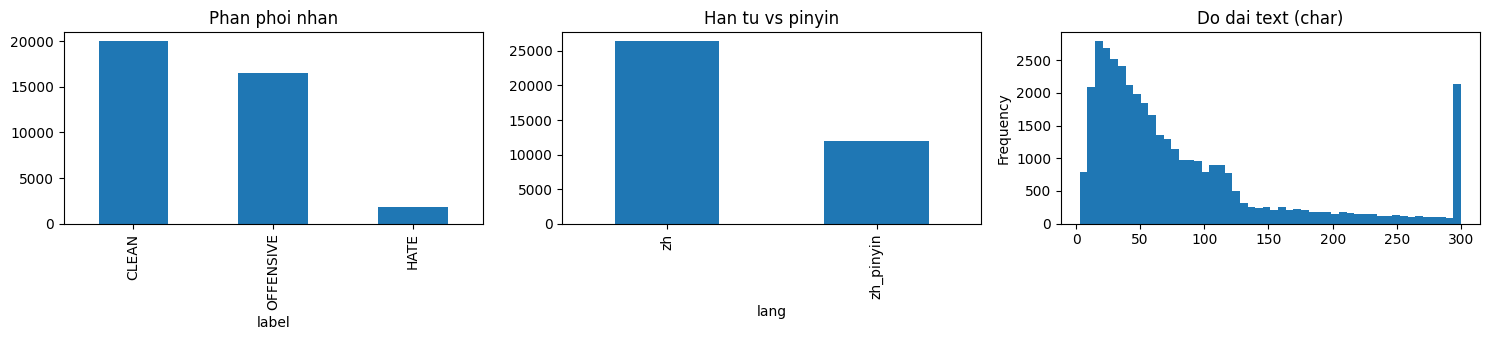

In [ ]:
import matplotlib.pyplot as plt
full_aug = pd.concat([train_df, val_df, test_df], ignore_index=True)
fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
full_aug.label.map(dict(enumerate(LABELS))).value_counts().plot.bar(ax=ax[0], title="Phan phoi nhan")
full_aug.lang.value_counts().plot.bar(ax=ax[1], title="Han tu vs pinyin")
full_aug.text.str.len().clip(0, 300).plot.hist(bins=50, ax=ax[2], title="Do dai text (char)")
plt.tight_layout(); plt.show()


## 5. Machine Learning rút gọn: 3 classifier + Soft Voting

TF-IDF **word 1–2 gram + char 3–5 gram** — char n-gram đặc biệt quan trọng với tiếng Trung (không tách từ) và bắt được pinyin lách từ (`c a o n i m a`). Giữ 3 model nhanh nhất (LogReg, LinearSVC, XGBoost) + Soft Voting, giống bản demo đa ngôn ngữ.

In [ ]:
import time
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import VotingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import f1_score, accuracy_score, classification_report
from xgboost import XGBClassifier

ml_table, BEST_ML = pd.DataFrame(), None
if RUN_ML:
    ml_train = train_df.sample(min(N_ML_SAMPLE, len(train_df)), random_state=SEED)
    Xtr_txt, ytr = ml_train.text.tolist(), ml_train.label.values
    Xte_txt, yte = test_df.text.tolist(), test_df.label.values

    vec_w = TfidfVectorizer(ngram_range=(1, 2), max_features=60_000, sublinear_tf=True)
    vec_c = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), max_features=80_000, sublinear_tf=True)
    Xtr = hstack([vec_w.fit_transform(Xtr_txt), vec_c.fit_transform(Xtr_txt)]).tocsr()
    Xte = hstack([vec_w.transform(Xte_txt),  vec_c.transform(Xte_txt)]).tocsr()
    print("TF-IDF shape:", Xtr.shape)

    MODELS = {
        "LogisticRegression": LogisticRegression(class_weight="balanced", max_iter=1000, C=4.0),
        "LinearSVC":          LinearSVC(class_weight="balanced", C=0.5),
        "XGBoost":            XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.3,
                                            tree_method="hist", eval_metric="mlogloss",
                                            random_state=SEED, n_jobs=-1),
    }
    ml_results = []
    for name, m in MODELS.items():
        t0 = time.time(); m.fit(Xtr, ytr); pred = m.predict(Xte)
        ml_results.append({"model": name, "accuracy": accuracy_score(yte, pred),
                           "macro_f1": f1_score(yte, pred, average="macro"),
                           "train_s": round(time.time() - t0, 1)})
        print(f"{name:22s} acc={ml_results[-1]['accuracy']:.4f} macroF1={ml_results[-1]['macro_f1']:.4f}")

    base = [("lr",  LogisticRegression(class_weight="balanced", max_iter=1000, C=4.0)),
            ("svc", CalibratedClassifierCV(LinearSVC(class_weight="balanced", C=0.5), cv=3)),
            ("xgb", XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.3,
                                  tree_method="hist", eval_metric="mlogloss",
                                  random_state=SEED, n_jobs=-1))]
    ens = VotingClassifier(base, voting="soft", n_jobs=-1)
    t0 = time.time(); ens.fit(Xtr, ytr); pred = ens.predict(Xte)
    ml_results.append({"model": "Ensemble-SoftVoting", "accuracy": accuracy_score(yte, pred),
                       "macro_f1": f1_score(yte, pred, average="macro"),
                       "train_s": round(time.time() - t0, 1)})

    ml_table = pd.DataFrame(ml_results).sort_values("macro_f1", ascending=False).reset_index(drop=True)
    BEST_ML = ml_table.iloc[0]
    print(); print(ml_table.to_string(index=False))
    print(f"\n>>> ML tot nhat: {BEST_ML.model} (macro-F1 {BEST_ML.macro_f1:.4f})")
    print("Luu y: du lieu lech nhan -> macro-F1 la metric chinh, accuracy chi tham khao")


TF-IDF shape: (20000, 140000)
LogisticRegression     acc=0.7650 macroF1=0.5456
LinearSVC              acc=0.7683 macroF1=0.5436
XGBoost                acc=0.7513 macroF1=0.5230

              model  accuracy  macro_f1  train_s
 LogisticRegression  0.764960  0.545618     44.0
          LinearSVC  0.768325  0.543575      1.9
Ensemble-SoftVoting  0.784907  0.540462    459.6
            XGBoost  0.751262  0.523032    459.0

>>> ML tot nhat: LogisticRegression (macro-F1 0.5456)
Luu y: du lieu lech nhan -> macro-F1 la metric chinh, accuracy chi tham khao


## 6. Deep Learning: Fine-tune XLM-RoBERTa-base — **1 config demo (đã chỉnh cho zh-only)**

Config: **freeze embeddings + encoder layer 0–3** (mở nhiều layer hơn bản đa ngôn ngữ vì chỉ có 1 nguồn dữ liệu), LR 2e-5, **3 epoch**, batch 32, fp16 → ~45–60 phút trên T4. Loss = **CrossEntropy + class weight** (bỏ focal — run trước dùng focal trên dữ liệu zh-only bị sập macro-F1 còn 0.34), early stopping theo macro-F1 trên val.

Dùng đúng `FacebookAI/xlm-roberta-base` → tokenizer + cấu trúc ONNX **giống hệt** model hiện tại trong `demo/models/`, chỉ khác trọng số.

In [ ]:
import inspect
from collections import Counter
from datasets import Dataset as HFDataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, EarlyStoppingCallback, set_seed)

MODEL_NAME = "FacebookAI/xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def to_hf(df): return HFDataset.from_pandas(df[["text", "label"]].reset_index(drop=True))
ds_tok = {}
for split, d in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    ds_tok[split] = to_hf(d).map(lambda b: tokenizer(b["text"], truncation=True, max_length=MAX_LEN),
                                 batched=True, remove_columns=["text"])

cnt = Counter(train_df.label); n_total = sum(cnt.values())
class_weights = torch.tensor([n_total / (len(LABELS) * cnt[i]) for i in range(len(LABELS))],
                             dtype=torch.float)
print("Class weights:", {l: round(float(w), 3) for l, w in zip(LABELS, class_weights)})

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(-1)
    out = {"macro_f1": f1_score(labels, preds, average="macro"),
           "accuracy": accuracy_score(labels, preds)}
    for i, v in enumerate(f1_score(labels, preds, average=None)):
        out[f"f1_{LABELS[i]}"] = v
    return out

class WeightedCETrainer(Trainer):
    # CrossEntropy + class weights. BO focal loss: run zh-only truoc dung focal
    # bi sap macro-F1 (OFFENSIVE F1 ~0.04) — focal + weights tren dataset 1 nguon
    # de lam model under-confident; CE + weights la lua chon an toan chuan.
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = torch.nn.functional.cross_entropy(
            outputs.logits, labels, weight=class_weights.to(outputs.logits.device))
        return (loss, outputs) if return_outputs else loss

def freeze(model, freeze_emb, freeze_upto):
    if freeze_emb:
        for p in model.roberta.embeddings.parameters(): p.requires_grad = False
    for i, layer in enumerate(model.roberta.encoder.layer):
        if i <= freeze_upto:
            for p in layer.parameters(): p.requires_grad = False
    n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n_all   = sum(p.numel() for p in model.parameters())
    print(f"  Trainable: {n_train/1e6:.1f}M / {n_all/1e6:.1f}M params")
    return model


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/30001 [00:00<?, ? examples/s]

Map:   0%|          | 0/4160 [00:00<?, ? examples/s]

Map:   0%|          | 0/4161 [00:00<?, ? examples/s]

Class weights: {'CLEAN': 0.64, 'OFFENSIVE': 0.773, 'HATE': 6.925}


In [ ]:
# ---------- Train 1 config demo: freeze bottom-6 ----------
# zh-only kho hon ban da ngon ngu (1 nguon du lieu) -> mo them layer (freeze 0-3),
# LR thap hon, 3 epoch (~45-60 phut T4). Run truoc freeze-6/2ep/focal -> macro-F1 0.34, KHONG dat.
CFG = dict(name="zh_freeze_bottom4", freeze_emb=True, freeze_upto=3, lr=2e-5, epochs=3, bs=32)

def make_args(cfg):
    kw = dict(output_dir=f"./out/{cfg['name']}", num_train_epochs=cfg["epochs"],
              learning_rate=cfg["lr"], per_device_train_batch_size=cfg["bs"],
              per_device_eval_batch_size=128, warmup_ratio=0.1,
              fp16=torch.cuda.is_available(), logging_steps=100,
              save_total_limit=1, save_strategy="epoch",
              load_best_model_at_end=True, metric_for_best_model="macro_f1",
              report_to="none", seed=SEED)
    sig = inspect.signature(TrainingArguments.__init__).parameters
    kw["eval_strategy" if "eval_strategy" in sig else "evaluation_strategy"] = "epoch"
    return TrainingArguments(**kw)

print(f"===== {CFG['name']} | lr={CFG['lr']} epochs={CFG['epochs']} =====")
set_seed(SEED)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(LABELS),
    id2label=dict(enumerate(LABELS)), label2id=LABEL2ID)
model = freeze(model, CFG["freeze_emb"], CFG["freeze_upto"])

tkw = dict(model=model, args=make_args(CFG),
           train_dataset=ds_tok["train"], eval_dataset=ds_tok["validation"],
           compute_metrics=compute_metrics,
           callbacks=[EarlyStoppingCallback(early_stopping_patience=2)])
if "processing_class" in inspect.signature(Trainer.__init__).parameters:
    tkw["processing_class"] = tokenizer
else:
    tkw["tokenizer"] = tokenizer
best_trainer = WeightedCETrainer(**tkw)

t0 = time.time(); best_trainer.train()
val_metrics = best_trainer.evaluate()
print(f"\nVal macro-F1={val_metrics['eval_macro_f1']:.4f} "
      f"acc={val_metrics['eval_accuracy']:.4f} | {((time.time()-t0)/60):.1f} phut")
BEST_CFG = CFG["name"]
torch.cuda.empty_cache()


===== zh_freeze_bottom4 | lr=2e-05 epochs=3 =====


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at FacebookAI/xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Trainable: 57.3M / 278.0M params


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy,F1 Clean,F1 Offensive,F1 Hate
1,0.919000,0.874923,0.467299,0.571635,0.817532,0.450000,0.134364
2,0.825600,0.860622,0.579440,0.750481,0.855154,0.719704,0.163462
3,0.763500,0.901337,0.561634,0.711538,0.851747,0.675567,0.157590



Val macro-F1=0.5794 acc=0.7505 | 9.4 phut


## 7. Đánh giá test + so sánh ML vs DL (kèm F1 riêng Hán tự / pinyin)

early stopping required metric_for_best_model, but did not find eval_macro_f1 so early stopping is disabled


              precision    recall  f1-score   support

       CLEAN     0.8369    0.8764    0.8562      2160
   OFFENSIVE     0.7934    0.6591    0.7200      1801
        HATE     0.1067    0.2150    0.1426       200

    accuracy                         0.7505      4161
   macro avg     0.5790    0.5835    0.5729      4161
weighted avg     0.7830    0.7505    0.7630      4161



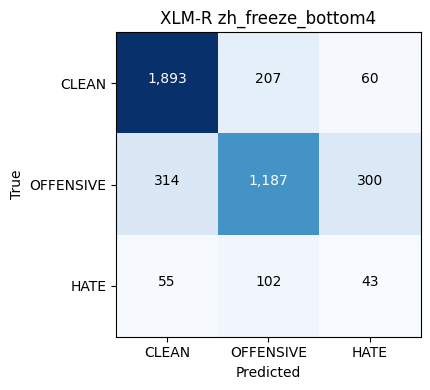

lang=zh_pinyin  n=   960 macroF1=0.3905
lang=zh         n= 3,201 macroF1=0.6263

======= BANG TONG KET ML vs DL (test) =======
                    model  accuracy  macro_f1
XLM-R (zh_freeze_bottom4)  0.750541  0.572947
       LogisticRegression  0.764960  0.545618
                LinearSVC  0.768325  0.543575
      Ensemble-SoftVoting  0.784907  0.540462
                  XGBoost  0.751262  0.523032


In [ ]:
from sklearn.metrics import confusion_matrix

test_metrics = best_trainer.evaluate(ds_tok["test"], metric_key_prefix="test")
pred_logits = best_trainer.predict(ds_tok["test"]).predictions
dl_pred = pred_logits.argmax(-1)
y_test = np.array(test_df.label.values)

print(classification_report(y_test, dl_pred, target_names=LABELS, digits=4))
cm = confusion_matrix(y_test, dl_pred)
fig, ax = plt.subplots(figsize=(4.5, 4)); im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(3), LABELS); ax.set_yticks(range(3), LABELS)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{cm[i,j]:,}", ha="center",
                color="white" if cm[i,j] > cm.max()/2 else "black")
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(f"XLM-R {BEST_CFG}")
plt.tight_layout(); plt.show()

# F1 rieng Han tu vs pinyin — kiem tra model co "hieu" phien am khong
for lg in test_df.lang.unique():
    m = (test_df.lang == lg).values
    if m.sum() > 20:
        print(f"lang={lg:10s} n={m.sum():6,} macroF1={f1_score(y_test[m], dl_pred[m], average='macro'):.4f}")

rows = [] if ml_table.empty else [ml_table[["model", "accuracy", "macro_f1"]]]
rows.append(pd.DataFrame([{"model": f"XLM-R ({BEST_CFG})",
                           "accuracy": test_metrics["test_accuracy"],
                           "macro_f1": test_metrics["test_macro_f1"]}]))
summary = pd.concat(rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)
print(); print("======= BANG TONG KET ML vs DL (test) ======="); print(summary.to_string(index=False))


# Guard: model phai dat muc toi thieu moi dang mang di demo
if test_metrics["test_macro_f1"] < 0.5:
    print("\n" + "!" * 70)
    print("!!! CANH BAO: test macro-F1 = %.3f < 0.5 — model chua dat de demo." % test_metrics["test_macro_f1"])
    print("!!! Tham khao: ban da ngon ngu dat 0.677. Dung dung model nay, bao lai de chinh tiep.")
    print("!" * 70)


## 8. Demo định tính (Hán tự / pinyin có dấu / pinyin không dấu / lách từ)

In [ ]:
best_model = best_trainer.model.eval().to(DEVICE)

@torch.no_grad()
def predict(texts):
    enc = tokenizer([clean_text(t) for t in texts], truncation=True, max_length=MAX_LEN,
                    padding=True, return_tensors="pt").to(DEVICE)
    probs = torch.softmax(best_model(**enc).logits, -1).cpu().numpy()
    return [{"text": t, "pred": LABELS[p.argmax()],
             **{l: round(float(x), 3) for l, x in zip(LABELS, p)}}
            for t, p in zip(texts, probs)]

DEMO = [
    # --- Han tu sach ---
    "今天的课很有意思，谢谢老师",
    "老师讲得很好，我学到了很多东西",
    # --- Han tu vi pham ---
    "你就是个白痴，滚",
    "傻逼玩意儿，去死吧",
    "操你妈",
    "操 你 妈",                          # lach tu bang khoang trang
    # --- Pinyin khong dau (kieu go pho bien nhat) ---
    "jin tian de ke hen you yi si, xie xie lao shi",
    "ni jiu shi ge bai chi, gun",
    "cao ni ma",
    "sha bi wan yi er, qu si ba",
    # --- Pinyin co dau thanh ---
    "nǐ jiù shì gè bái chī, gǔn",
    "shǎ bī",
]
pd.DataFrame(predict(DEMO))


,text,pred,CLEAN,OFFENSIVE,HATE
0,今天的课很有意思，谢谢老师,CLEAN,0.979,0.014,0.008
1,老师讲得很好，我学到了很多东西,CLEAN,0.978,0.014,0.008
2,你就是个白痴，滚,CLEAN,0.465,0.403,0.132
3,傻逼玩意儿，去死吧,OFFENSIVE,0.332,0.414,0.254
4,操你妈,CLEAN,0.873,0.086,0.041
5,操 你 妈,CLEAN,0.923,0.053,0.024
6,"jin tian de ke hen you yi si, xie xie lao shi",CLEAN,0.837,0.107,0.056
7,"ni jiu shi ge bai chi, gun",CLEAN,0.841,0.105,0.054
8,cao ni ma,CLEAN,0.640,0.233,0.127
9,"sha bi wan yi er, qu si ba",CLEAN,0.716,0.173,0.110


## 9. Export **ONNX + quantize INT8** + đo latency (mục tiêu p95 < 80ms CPU)

Output chính — thư mục `artifacts/xlmr_onnx_int8/` có **cùng cấu trúc file** với model hiện tại (`model_quantized.onnx`, `tokenizer.json`, `sentencepiece.bpe.model`, `config.json`…) → copy đè vào `demo/models/xlmr_onnx_int8/` là xong.

In [ ]:
# --- Export ONNX + quantize INT8 — KHONG dung optimum ---
# torch.onnx export truc tiep (thu exporter cu truoc, fail thi dung dynamo),
# quantize bang onnxruntime. Output cung dinh dang cu: model_quantized.onnx + tokenizer
# -> ORTModelForSequenceClassification.from_pretrained() phia service load nhu binh thuong.
import shutil

def bench(fn, n=200, warmup=20):
    for _ in range(warmup): fn()
    ts = []
    for _ in range(n):
        t0 = time.perf_counter(); fn(); ts.append((time.perf_counter() - t0) * 1000)
    ts.sort(); return ts[len(ts)//2], ts[int(len(ts)*0.95)]

sample = "你就是个白痴，滚"
enc = tokenizer(sample, return_tensors="pt", truncation=True, max_length=MAX_LEN).to(DEVICE)
with torch.no_grad():
    p50, p95 = bench(lambda: best_model(**enc))
print(f"PyTorch {DEVICE}: p50={p50:.1f}ms p95={p95:.1f}ms")

SAVE_DIR = "./artifacts/xlmr_best"
best_trainer.save_model(SAVE_DIR); tokenizer.save_pretrained(SAVE_DIR)

try:
    from onnxruntime import InferenceSession
    from onnxruntime.quantization import quantize_dynamic, QuantType

    # Load lai model tu SAVE_DIR voi attention "eager" (matmul+softmax thuan)
    # -> exporter nao cung an duoc, khong dinh symbolic SDPA cua torch
    export_model = AutoModelForSequenceClassification.from_pretrained(
        SAVE_DIR, attn_implementation="eager").eval().cpu()

    class LogitsWrapper(torch.nn.Module):
        def __init__(self, m): super().__init__(); self.m = m
        def forward(self, input_ids, attention_mask):
            return self.m(input_ids=input_ids, attention_mask=attention_mask).logits

    wrap = LogitsWrapper(export_model)
    e = tokenizer(sample, return_tensors="pt", truncation=True, max_length=MAX_LEN)
    args = (e["input_ids"], e["attention_mask"])

    os.makedirs("./artifacts/xlmr_onnx", exist_ok=True)
    ONNX_FP32 = "./artifacts/xlmr_onnx/model.onnx"
    OUT_DIR = "./artifacts/xlmr_onnx_int8"
    EXPORT_KW = dict(input_names=["input_ids", "attention_mask"], output_names=["logits"],
                     dynamic_axes={"input_ids": {0: "batch", 1: "sequence"},
                                   "attention_mask": {0: "batch", 1: "sequence"},
                                   "logits": {0: "batch"}})

    # Thu lan luot 4 exporter — LUU Y: dynamo exporter chi ho tro opset >= 18
    # (run truoc fail vi ep opset 14 cho dynamo), torchscript exporter thi dung 14.
    def _try_export(name, **extra):
        try:
            torch.onnx.export(wrap, args, ONNX_FP32, **EXPORT_KW, **extra)
            print(f"Export OK ({name})")
            return True
        except Exception as ex:
            print(f"  [{name}] fail: {type(ex).__name__}: {str(ex)[:180]}")
            return False

    with torch.no_grad():
        exported = (
            _try_export("torchscript opset14", opset_version=14, dynamo=False)
            or _try_export("torchscript torch-cu", opset_version=14)
            or _try_export("dynamo opset18", opset_version=18, dynamo=True)
            or _try_export("dynamo default", dynamo=True)
        )
    if not exported:
        raise RuntimeError("Ca 4 exporter deu fail — gui cac dong [.. fail ..] o tren de debug")

    os.makedirs(OUT_DIR, exist_ok=True)
    quantize_dynamic(ONNX_FP32, f"{OUT_DIR}/model_quantized.onnx", weight_type=QuantType.QInt8)
    tokenizer.save_pretrained(OUT_DIR)
    shutil.copy(f"{SAVE_DIR}/config.json", f"{OUT_DIR}/config.json")  # id2label cho service
    print("Da luu:", sorted(os.listdir(OUT_DIR)))

    # Sanity check + latency bang onnxruntime thuan (khong can optimum)
    sess = InferenceSession(f"{OUT_DIR}/model_quantized.onnx", providers=["CPUExecutionProvider"])

    def onnx_logits(s):
        en = tokenizer(s, return_tensors="np", truncation=True, max_length=MAX_LEN)
        return sess.run(None, {"input_ids": en["input_ids"].astype(np.int64),
                               "attention_mask": en["attention_mask"].astype(np.int64)})[0]

    p50, p95 = bench(lambda: onnx_logits(sample))
    print(f"ONNX INT8 CPU: p50={p50:.1f}ms p95={p95:.1f}ms  (target p95 < 80ms)")
    for s in [sample, "cao ni ma", "jin tian de ke hen you yi si", "今天的课很有意思，谢谢老师"]:
        pt = LABELS[int(best_model(**tokenizer(s, return_tensors="pt", truncation=True,
                                               max_length=MAX_LEN).to(DEVICE)).logits.argmax())]
        print(f"  {s!r:48s} ONNX={LABELS[int(onnx_logits(s).argmax())]:9s} | PyTorch={pt}")
except Exception:
    import traceback
    traceback.print_exc()
    print("\n>>> Export ONNX loi — model da train van o ./artifacts/xlmr_best, cell cuoi se tu dong goi ban PyTorch")


PyTorch cuda: p50=11.5ms p95=14.1ms

>>> Export ONNX loi — model da train van o ./artifacts/xlmr_best, cell cuoi se tu dong goi ban PyTorch


Traceback (most recent call last):
  File "/tmp/ipykernel_1891/2610010163.py", line 25, in <cell line: 0>
    from onnxruntime.quantization import quantize_dynamic, QuantType
  File "/usr/local/lib/python3.12/dist-packages/onnxruntime/quantization/__init__.py", line 1, in <module>
    from .calibrate import (  # noqa: F401
  File "/usr/local/lib/python3.12/dist-packages/onnxruntime/quantization/calibrate.py", line 20, in <module>
    import onnx
ModuleNotFoundError: No module named 'onnx'


## 10. Lưu artifact + tổng kết + tải về

In [ ]:
import json as _json

os.makedirs("./artifacts", exist_ok=True)
meta = {
    "model_version": "xlmr-catspeak-demo-zh-v1.0",
    "note": "DEMO ZH — chi tieng Trung: COLD + augment pinyin (pypinyin). "
            "Drop-in thay demo/models/xlmr_onnx_int8. Ban da ngon ngu: train_text_classifier_demo_colab.ipynb",
    "labels": LABELS,
    "datasets_loaded": ["cold", "cold_pinyin(augment)"],
    "train_size": len(train_df),
    "pinyin_train_samples": int((train_df.lang == "zh_pinyin").sum()),
    "best_ml": None if BEST_ML is None else {"model": str(BEST_ML.model),
                                             "accuracy": float(BEST_ML.accuracy),
                                             "macro_f1": float(BEST_ML.macro_f1)},
    "dl_config": BEST_CFG,
    "dl_test": {k: float(v) for k, v in test_metrics.items() if isinstance(v, (int, float))},
    "thresholds_suggested": {"block": 0.90, "review": 0.50},
}
with open("./artifacts/model_meta.json", "w") as f: _json.dump(meta, f, indent=2, ensure_ascii=False)
summary.to_csv("./artifacts/summary_ml_vs_dl.csv", index=False)
print(_json.dumps(meta, indent=2, ensure_ascii=False))

# Zip artifacts cho demo. Neu export ONNX loi -> tu dong dong goi model PyTorch
# (xlmr_best) de KHONG MAT model da train; service co fallback HF nen van chay duoc.
HAVE_ONNX = os.path.isdir("./artifacts/xlmr_onnx_int8")
if HAVE_ONNX:
    os.system("zip -qr artifacts_demo_zh.zip artifacts/xlmr_onnx_int8 artifacts/model_meta.json artifacts/summary_ml_vs_dl.csv")
else:
    print("!!! Khong thay artifacts/xlmr_onnx_int8 (export ONNX loi — xem output muc 9)")
    print("!!! Dong goi model PyTorch xlmr_best thay the (nang hon ~1GB nhung khong mat cong train)")
    os.system("zip -qr artifacts_demo_zh.zip artifacts/xlmr_best artifacts/model_meta.json artifacts/summary_ml_vs_dl.csv")
!ls -lh artifacts_demo_zh.zip

# Tu dong tai ve khi chay tren Colab
if IN_COLAB:
    try:
        from google.colab import files
        files.download("artifacts_demo_zh.zip")
    except Exception as e:
        print("Tai thu cong tu panel Files ben trai:", e)
if HAVE_ONNX:
    print("Giai nen -> copy artifacts/xlmr_onnx_int8/ vao moderation/models/xlmr_onnx_int8_zh/ (hoac de vao demo/models/)")
else:
    print("Giai nen -> copy artifacts/xlmr_best/ vao moderation/models/xlmr_best/ (fallback HF, cham hon ONNX)")


{
  "model_version": "xlmr-catspeak-demo-zh-v1.0",
  "note": "DEMO ZH — chi tieng Trung: COLD + augment pinyin (pypinyin). Drop-in thay demo/models/xlmr_onnx_int8. Ban da ngon ngu: train_text_classifier_demo_colab.ipynb",
  "labels": [
    "CLEAN",
    "OFFENSIVE",
    "HATE"
  ],
  "datasets_loaded": [
    "cold",
    "cold_pinyin(augment)"
  ],
  "train_size": 30001,
  "pinyin_train_samples": 10038,
  "best_ml": {
    "model": "LogisticRegression",
    "accuracy": 0.7649603460706561,
    "macro_f1": 0.5456181994391381
  },
  "dl_config": "zh_freeze_bottom4",
  "dl_test": {
    "test_loss": 0.812893271446228,
    "test_macro_f1": 0.5729474794024657,
    "test_accuracy": 0.7505407354001442,
    "test_f1_CLEAN": 0.8561736770691994,
    "test_f1_OFFENSIVE": 0.7200485289657265,
    "test_f1_HATE": 0.14262023217247097,
    "test_runtime": 5.739,
    "test_samples_per_second": 725.036,
    "test_steps_per_second": 5.75,
    "epoch": 3.0
  },
  "thresholds_suggested": {
    "block": 0.9,
   

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Giai nen -> copy artifacts/xlmr_best/ vao moderation/models/xlmr_best/ (fallback HF, cham hon ONNX)
